In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
from IPython.display import Audio
import warnings
warnings.filterwarnings('ignore')


In [3]:
DATASET_PATH = '/kaggle/input/common-voice'
METADATA_PATH = os.path.join(DATASET_PATH, 'cv-valid-train.csv')
AUDIO_PATH = os.path.join(DATASET_PATH, 'cv-valid-train')


In [4]:
df = pd.read_csv(METADATA_PATH)
df.head()

,filename,text,up_votes,down_votes,age,gender,accent,duration
0,cv-valid-train/sample-000000.mp3,learn to recognize omens and follow them the o...,1,0,NaN,NaN,NaN,NaN
1,cv-valid-train/sample-000001.mp3,everything in the universe evolved he said,1,0,NaN,NaN,NaN,NaN
2,cv-valid-train/sample-000002.mp3,you came so that you could learn about your dr...,1,0,NaN,NaN,NaN,NaN
3,cv-valid-train/sample-000003.mp3,so now i fear nothing because it was those ome...,1,0,NaN,NaN,NaN,NaN
4,cv-valid-train/sample-000004.mp3,if you start your emails with greetings let me...,3,2,NaN,NaN,NaN,NaN


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195776 entries, 0 to 195775
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   filename    195776 non-null  object 
 1   text        195776 non-null  object 
 2   up_votes    195776 non-null  int64  
 3   down_votes  195776 non-null  int64  
 4   age         73768 non-null   object 
 5   gender      74059 non-null   object 
 6   accent      64711 non-null   object 
 7   duration    0 non-null       float64
dtypes: float64(1), int64(2), object(5)
memory usage: 11.9+ MB


In [6]:
df['gender'].value_counts()


gender
male      55029
female    18249
other       781
Name: count, dtype: int64

In [7]:
df['age'].value_counts()


age
twenties     23003
thirties     18303
fourties     11100
fifties       9466
teens         5441
sixties       4584
seventies     1632
eighties       239
Name: count, dtype: int64

In [8]:
df = df[['filename', 'gender', 'age']]
df.dropna(inplace=True)

df.reset_index(drop=True, inplace=True)
df.head()


,filename,gender,age
0,cv-valid-train/sample-000005.mp3,female,twenties
1,cv-valid-train/sample-000008.mp3,male,seventies
2,cv-valid-train/sample-000013.mp3,female,thirties
3,cv-valid-train/sample-000014.mp3,male,sixties
4,cv-valid-train/sample-000019.mp3,male,fifties


In [9]:
sample = df.iloc[0]
audio_file = os.path.join(AUDIO_PATH, sample['filename'])

print("Gender:", sample['gender'])
print("Age Group:", sample['age'])

Audio(audio_file)


Gender: female
Age Group: twenties


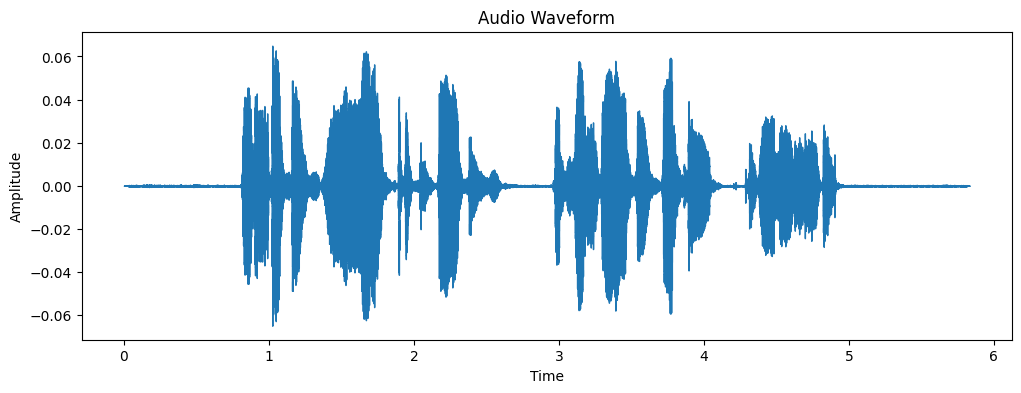

In [10]:
y, sr = librosa.load(audio_file)

plt.figure(figsize=(12, 4))
librosa.display.waveshow(y, sr=sr)
plt.title("Audio Waveform")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()


In [12]:
from tqdm import tqdm

In [13]:
def extract_features(audio_path):
    try:
        y, sr = librosa.load(audio_path, duration=3)

        mfcc = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40).T, axis=0)

        chroma = np.mean(librosa.feature.chroma_stft(y=y, sr=sr).T, axis=0)

        zcr = np.mean(librosa.feature.zero_crossing_rate(y))

        features = np.hstack((mfcc, chroma, zcr))

        return features

    except Exception as e:
        return None


In [14]:
sample = df.iloc[0]
audio_path = os.path.join(AUDIO_PATH, sample['filename'])

features = extract_features(audio_path)

print("Feature shape:", features.shape)
features


Feature shape: (53,)


array([-5.84400818e+02,  1.06127731e+02,  2.65480852e+00,  4.14864273e+01,
       -1.06339083e+01,  2.48297715e+00, -1.59722471e+01, -6.34023714e+00,
       -8.88287604e-01, -1.33573294e+01, -1.54904499e+01, -1.47399158e+01,
       -6.94009495e+00, -7.55700397e+00, -4.38859558e+00, -8.64024734e+00,
       -3.71433949e+00, -2.12577057e+00, -9.04439259e+00, -8.59402084e+00,
       -3.13765359e+00, -6.25979376e+00, -1.12416935e+01, -2.51102805e+00,
       -6.22278357e+00, -7.05616999e+00, -6.33191824e-01, -3.18086505e+00,
       -3.90390301e+00, -2.05115080e+00, -3.26881623e+00, -1.57030904e+00,
        1.96113884e+00,  2.87991738e+00,  7.43187714e+00,  6.47214365e+00,
        5.51680708e+00,  3.97412252e+00,  4.21744585e+00, -2.86397040e-01,
        2.67881036e-01,  1.88997209e-01,  1.90433994e-01,  3.00022900e-01,
        3.60371739e-01,  3.25394064e-01,  4.14537072e-01,  5.33282280e-01,
        4.94593531e-01,  3.94696951e-01,  3.27502757e-01,  3.46905798e-01,
        8.45477764e-02])

In [15]:
X = []
y_gender = []
y_age = []

for index, row in tqdm(df.iterrows(), total=len(df)):
    audio_path = os.path.join(AUDIO_PATH, row['filename'])
    features = extract_features(audio_path)
    
    if features is not None:
        X.append(features)
        y_gender.append(row['gender'])
        y_age.append(row['age'])


100%|██████████| 73466/73466 [44:51<00:00, 27.29it/s]  


In [16]:
X = np.array(X)
y_gender = np.array(y_gender)
y_age = np.array(y_age)

print("Feature matrix shape:", X.shape)
print("Gender labels:", y_gender.shape)
print("Age labels:", y_age.shape)


Feature matrix shape: (73466, 53)
Gender labels: (73466,)
Age labels: (73466,)


In [17]:
from sklearn.preprocessing import LabelEncoder

gender_encoder = LabelEncoder()
y_gender_encoded = gender_encoder.fit_transform(y_gender)

gender_encoder.classes_


array(['female', 'male', 'other'], dtype='<U6')

In [18]:
age_encoder = LabelEncoder()
y_age_encoded = age_encoder.fit_transform(y_age)

age_encoder.classes_


array(['eighties', 'fifties', 'fourties', 'seventies', 'sixties', 'teens',
       'thirties', 'twenties'], dtype='<U9')

In [19]:
print(X.shape)
print(y_gender_encoded.shape)

(73466, 53)
(73466,)


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_gender_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_gender_encoded
)


In [21]:
from sklearn.ensemble import RandomForestClassifier

gender_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)


In [23]:
gender_model.fit(X_train, y_train)


RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [24]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = gender_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.9199673336055533
              precision    recall  f1-score   support

           0       0.89      0.81      0.85      3620
           1       0.93      0.97      0.95     10919
           2       1.00      0.06      0.12       155

    accuracy                           0.92     14694
   macro avg       0.94      0.61      0.64     14694
weighted avg       0.92      0.92      0.91     14694



In [25]:
sample = df.iloc[1]
audio_path = os.path.join(AUDIO_PATH, sample['filename'])

features = extract_features(audio_path).reshape(1, -1)

pred = gender_model.predict(features)[0]

if pred == 1:
    print("Predicted Gender: Male")
else:
    print("Predicted Gender: Female")


Predicted Gender: Male


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_age_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_age_encoded
)

In [29]:
age_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

age_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

In [30]:

y_pred = age_model.predict(X_test)

print("Age Model Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Age Model Accuracy: 0.6871512181842929
              precision    recall  f1-score   support

           0       1.00      0.42      0.59        48
           1       0.94      0.61      0.74      1888
           2       0.94      0.53      0.68      2183
           3       1.00      0.40      0.57       326
           4       1.00      0.50      0.67       917
           5       1.00      0.30      0.47      1088
           6       0.68      0.72      0.70      3658
           7       0.57      0.92      0.70      4586

    accuracy                           0.69     14694
   macro avg       0.89      0.55      0.64     14694
weighted avg       0.77      0.69      0.68     14694



In [31]:
sample = df.iloc[2]
audio_path = os.path.join(AUDIO_PATH, sample['filename'])

features = extract_features(audio_path).reshape(1, -1)

age_pred_encoded = age_model.predict(features)[0]
age_pred_label = age_encoder.inverse_transform([age_pred_encoded])[0]

print("Predicted Age Group:", age_pred_label)


Predicted Age Group: thirties


In [32]:
if age_pred_label in ['sixties', 'seventies', 'eighties']:
    print("Senior Citizen Detected")
    senior = True
else:
    print("Below 60")
    senior = False


Below 60


In [34]:
RAVDESS_PATH = '/kaggle/input/ravdess-emotional-speech-audio'

In [36]:
emotion_map = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}

In [37]:
emotion_X = []
emotion_y = []

for root, dirs, files in os.walk(RAVDESS_PATH):
    for file in files:
        if file.endswith('.wav'):
            emotion_code = file.split('-')[2]
            emotion_label = emotion_map.get(emotion_code)

            if emotion_label:
                audio_path = os.path.join(root, file)
                features = extract_features(audio_path)

                if features is not None:
                    emotion_X.append(features)
                    emotion_y.append(emotion_label)


In [38]:
from sklearn.preprocessing import LabelEncoder

emotion_encoder = LabelEncoder()
emotion_y_encoded = emotion_encoder.fit_transform(emotion_y)

emotion_encoder.classes_


array(['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad',
       'surprised'], dtype='<U9')

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    emotion_X,
    emotion_y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=emotion_y_encoded
)


In [40]:
emotion_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

emotion_model.fit(X_train, y_train)


RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

In [41]:
y_pred = emotion_model.predict(X_test)

print("Emotion Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Emotion Accuracy: 0.9340277777777778
              precision    recall  f1-score   support

           0       0.90      1.00      0.95        76
           1       0.90      0.97      0.94        77
           2       0.97      0.92      0.95        77
           3       0.90      0.97      0.94        77
           4       0.95      0.90      0.92        77
           5       1.00      0.79      0.88        38
           6       1.00      0.90      0.95        77
           7       0.90      0.95      0.92        77

    accuracy                           0.93       576
   macro avg       0.94      0.92      0.93       576
weighted avg       0.94      0.93      0.93       576



In [43]:
def predict_emotion(audio_path):
    features = extract_features(audio_path).reshape(1, -1)
    pred = emotion_model.predict(features)[0]
    return emotion_encoder.inverse_transform([pred])[0]


In [44]:
def full_voice_analysis(audio_path):

    # Step 1: Gender
    features = extract_features(audio_path).reshape(1, -1)
    gender_pred = gender_model.predict(features)[0]

    if gender_pred == 0:
        return "Upload male voice"

    # Step 2: Age
    age_pred = age_model.predict(features)[0]
    age_label = age_encoder.inverse_transform([age_pred])[0]

    if age_label not in ['sixties', 'seventies', 'eighties']:
        return f"Male | Age Group: {age_label}"

    # Step 3: Emotion (Senior Citizen)
    emotion = predict_emotion(audio_path)
    return f"Male | Senior Citizen | Emotion: {emotion}"


In [45]:
import joblib

joblib.dump(gender_model, "/kaggle/working/gender_model.pkl")
joblib.dump(age_model, "/kaggle/working/age_model.pkl")
joblib.dump(emotion_model, "/kaggle/working/emotion_model.pkl")

joblib.dump(age_encoder, "/kaggle/working/age_encoder.pkl")
joblib.dump(emotion_encoder, "/kaggle/working/emotion_encoder.pkl")

print("Saved files:")
print(os.listdir("/kaggle/working"))


Saved files:
['gender_model.pkl', 'emotion_encoder.pkl', '.virtual_documents', 'age_encoder.pkl', 'emotion_model.pkl', 'age_model.pkl']
